In [10]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import joblib
import warnings
warnings.filterwarnings('ignore')

print(f" Thời gian hiện tại: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

 Thời gian hiện tại: 2025-11-10 13:57:09


In [11]:
print("\n" + "="*70)
print("LOAD MÔ HÌNH VÀ SCALER")
print("="*70 + "\n")

# Load mô hình từ dữ liệu gốc
try:
    model_original = joblib.load('best_pm25_model_original.pkl')
    print(" Đã load mô hình từ dữ liệu GỐC: best_pm25_model_original.pkl")
    print(f"   Loại mô hình: {type(model_original).__name__}")
except Exception as e:
    print(f" Lỗi khi load mô hình gốc: {e}")
    model_original = None

# Load mô hình từ dữ liệu đã chuẩn hóa
try:
    model_scaled = joblib.load('best_pm25_model_scaled.pkl')
    print(" Đã load mô hình từ dữ liệu ĐÃ CHUẨN HÓA: best_pm25_model_scaled.pkl")
    print(f"   Loại mô hình: {type(model_scaled).__name__}")
except Exception as e:
    print(f" Lỗi khi load mô hình scaled: {e}")
    model_scaled = None

# Load StandardScaler (cần cho mô hình scaled)
try:
    scaler = joblib.load('pm25_scaler.pkl')
    print(" Đã load StandardScaler: pm25_scaler.pkl")
except Exception as e:
    print(f"  Không tìm thấy scaler: {e}")
    print(f"   (Nếu mô hình scaled không chạy được, cần tạo scaler từ training notebook)")
    scaler = None

print("\n" + "="*70)


LOAD MÔ HÌNH VÀ SCALER

 Đã load mô hình từ dữ liệu GỐC: best_pm25_model_original.pkl
   Loại mô hình: XGBRegressor
 Đã load mô hình từ dữ liệu ĐÃ CHUẨN HÓA: best_pm25_model_scaled.pkl
   Loại mô hình: XGBRegressor
 Đã load StandardScaler: pm25_scaler.pkl



In [12]:
print("\n" + "="*70)
print("LOAD DỮ LIỆU LỊCH SỬ")
print("="*70 + "\n")

# Load dữ liệu để tính giá trị trung bình các features
try:
    df = pd.read_csv('weather_data_hanoi.csv')
    print(f" Đã load dữ liệu: weather_data_hanoi.csv")
    print(f"   Shape: {df.shape}")
    print(f"   Các cột: {list(df.columns)}")
    
    # Xử lý datetime nếu cần
    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'], format='%Y-%m-%d:%H')
    
except Exception as e:
    print(f" Lỗi khi load dữ liệu: {e}")
    df = None

print("\n" + "="*70)


LOAD DỮ LIỆU LỊCH SỬ

 Đã load dữ liệu: weather_data_hanoi.csv
   Shape: (24275, 11)
   Các cột: ['aqi', 'co', 'datetime', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'timestamp_local', 'timestamp_utc', 'ts']



In [13]:
print("\n" + "="*70)
print("CHUẨN BỊ THỜI GIAN DỰ ĐOÁN")
print("="*70 + "\n")

# Xác định thời gian bắt đầu dự đoán (sau ngày của dữ liệu cuối cùng trong df)
start_date = df['datetime'].max() + timedelta(days=1)
start_date = start_date.replace(hour=0, minute=0, second=0, microsecond=0)
end_date = start_date + timedelta(days=7)

print(f" Khoảng thời gian dự đoán:")
print(f"   Từ: {start_date.strftime('%Y-%m-%d %H:%M')}")
print(f"   Đến: {end_date.strftime('%Y-%m-%d %H:%M')}")
print(f"   Tổng: 168 giờ (7 ngày × 24 giờ)")

# Tạo danh sách timestamps
future_dates = []
current = start_date
for i in range(168):
    future_dates.append(current)
    current += timedelta(hours=1)

print(f"\n Đã tạo {len(future_dates)} timestamps")
print(f"   Timestamp đầu tiên: {future_dates[0]}")
print(f"   Timestamp cuối cùng: {future_dates[-1]}")

print("\n" + "="*70)


CHUẨN BỊ THỜI GIAN DỰ ĐOÁN

 Khoảng thời gian dự đoán:
   Từ: 2025-11-10 00:00
   Đến: 2025-11-17 00:00
   Tổng: 168 giờ (7 ngày × 24 giờ)

 Đã tạo 168 timestamps
   Timestamp đầu tiên: 2025-11-10 00:00:00
   Timestamp cuối cùng: 2025-11-16 23:00:00



In [15]:
print("\n" + "="*70)
print("TẠO FEATURES CHO 7 NGÀY TỚI")
print("="*70 + "\n")

# Tạo DataFrame với time features
future_df = pd.DataFrame({
    'datetime': future_dates,
    'year': [d.year for d in future_dates],
    'month': [d.month for d in future_dates],
    'day': [d.day for d in future_dates],
    'hour': [d.hour for d in future_dates],
    'weekday': [d.weekday() for d in future_dates]
})

print(" Đã tạo time features")
print(f"\n Preview time features:")
print(future_df.head())

# Tính giá trị trung bình các features khác từ dữ liệu lịch sử
print(f"\n Tính giá trị trung bình các environmental features...")

environmental_features = ['co', 'no2', 'o3', 'pm10', 'so2']

# Kiểm tra và tính mean
for feature in environmental_features:
    if feature in df.columns:
        mean_value = df[feature].mean()
        future_df[feature] = mean_value
        print(f"    {feature}: {mean_value:.4f}")
    else:
        print(f"     {feature}: Không tìm thấy trong dữ liệu")

feature_order = ['co', 'no2', 'o3', 'pm10', 'so2', 'year', 'month', 'day', 'hour', 'weekday']
future_df = future_df[['datetime'] + feature_order]

print(f"\n Hoàn tất tạo features!")
print(f"   Total features: {len(feature_order)}")
print(f"   Thứ tự features: {feature_order}")
print(f"\n Sample data với đầy đủ features:")
print(future_df.head())

print("\n" + "="*70)


TẠO FEATURES CHO 7 NGÀY TỚI

 Đã tạo time features

 Preview time features:
             datetime  year  month  day  hour  weekday
0 2025-11-10 00:00:00  2025     11   10     0        0
1 2025-11-10 01:00:00  2025     11   10     1        0
2 2025-11-10 02:00:00  2025     11   10     2        0
3 2025-11-10 03:00:00  2025     11   10     3        0
4 2025-11-10 04:00:00  2025     11   10     4        0

 Tính giá trị trung bình các environmental features...
    co: 614.0882
    no2: 31.8466
    o3: 53.3072
    pm10: 70.0068
    so2: 62.6566

 Hoàn tất tạo features!
   Total features: 10
   Thứ tự features: ['co', 'no2', 'o3', 'pm10', 'so2', 'year', 'month', 'day', 'hour', 'weekday']

 Sample data với đầy đủ features:
             datetime          co        no2         o3       pm10       so2  \
0 2025-11-10 00:00:00  614.088231  31.846636  53.307234  70.006805  62.65661   
1 2025-11-10 01:00:00  614.088231  31.846636  53.307234  70.006805  62.65661   
2 2025-11-10 02:00:00  614.08823

In [16]:
print("\n" + "="*70)
print("DỰ ĐOÁN VỚI MÔ HÌNH GỐC (ORIGINAL)")
print("="*70 + "\n")

if model_original is not None:
    # Chuẩn bị dữ liệu (loại bỏ cột datetime)
    X_future = future_df.drop(columns=['datetime'])
    
    print(f" Input shape: {X_future.shape}")
    print(f" Đang dự đoán với mô hình GỐC ({type(model_original).__name__})...")
    
    # Dự đoán
    predictions_original = model_original.predict(X_future)
    
    # Thêm vào DataFrame
    future_df['pm25_predicted_original'] = predictions_original
    
    print(f"\n Hoàn tất dự đoán với mô hình GỐC!")
    print(f"   Số dự đoán: {len(predictions_original)}")
    print(f"   PM2.5 Mean: {predictions_original.mean():.2f} µg/m³")
    print(f"   PM2.5 Min: {predictions_original.min():.2f} µg/m³")
    print(f"   PM2.5 Max: {predictions_original.max():.2f} µg/m³")
    print(f"   PM2.5 Std: {predictions_original.std():.2f} µg/m³")
    
    # Thống kê theo ngày
    print(f"\n Dự đoán trung bình theo từng ngày:")
    print("-" * 70)
    for day in range(7):
        day_start = start_date + timedelta(days=day)
        day_end = day_start + timedelta(days=1)
        
        day_mask = (future_df['datetime'] >= day_start) & (future_df['datetime'] < day_end)
        day_data = future_df[day_mask]
        
        if len(day_data) > 0:
            day_mean = day_data['pm25_predicted_original'].mean()
            day_min = day_data['pm25_predicted_original'].min()
            day_max = day_data['pm25_predicted_original'].max()
            
            print(f"   Ngày {day+1} ({day_start.strftime('%Y-%m-%d')}): "
                  f"Mean={day_mean:.2f}, Min={day_min:.2f}, Max={day_max:.2f}")
else:
    print(" Không thể dự đoán - Mô hình chưa được load")

print("\n" + "="*70)


DỰ ĐOÁN VỚI MÔ HÌNH GỐC (ORIGINAL)

 Input shape: (168, 10)
 Đang dự đoán với mô hình GỐC (XGBRegressor)...

 Hoàn tất dự đoán với mô hình GỐC!
   Số dự đoán: 168
   PM2.5 Mean: 52.93 µg/m³
   PM2.5 Min: 47.83 µg/m³
   PM2.5 Max: 57.28 µg/m³
   PM2.5 Std: 2.47 µg/m³

 Dự đoán trung bình theo từng ngày:
----------------------------------------------------------------------
   Ngày 1 (2025-11-10): Mean=50.26, Min=47.94, Max=52.47
   Ngày 2 (2025-11-11): Mean=50.15, Min=47.83, Max=52.36
   Ngày 3 (2025-11-12): Mean=53.88, Min=50.73, Max=56.91
   Ngày 4 (2025-11-13): Mean=53.09, Min=49.94, Max=56.12
   Ngày 5 (2025-11-14): Mean=53.94, Min=50.75, Max=56.23
   Ngày 6 (2025-11-15): Mean=53.94, Min=50.75, Max=56.23
   Ngày 7 (2025-11-16): Mean=55.21, Min=52.14, Max=57.28



In [17]:
print("\n" + "="*70)
print("DỰ ĐOÁN VỚI MÔ HÌNH ĐÃ CHUẨN HÓA (SCALED)")
print("="*70 + "\n")

if model_scaled is not None and scaler is not None:
    # Chuẩn bị dữ liệu (loại bỏ cột datetime và pm25_predicted_original)
    X_future = future_df.drop(columns=['datetime', 'pm25_predicted_original'])
    
    # Chuẩn hóa dữ liệu với StandardScaler
    print(f" Đang chuẩn hóa dữ liệu với StandardScaler...")
    X_future_scaled = scaler.transform(X_future)
    
    print(f" Input shape: {X_future_scaled.shape}")
    print(f" Đang dự đoán với mô hình ĐÃ CHUẨN HÓA ({type(model_scaled).__name__})...")
    
    # Dự đoán
    predictions_scaled = model_scaled.predict(X_future_scaled)
    
    # Thêm vào DataFrame
    future_df['pm25_predicted_scaled'] = predictions_scaled
    
    print(f"\n Hoàn tất dự đoán với mô hình ĐÃ CHUẨN HÓA!")
    print(f"   Số dự đoán: {len(predictions_scaled)}")
    print(f"   PM2.5 Mean: {predictions_scaled.mean():.2f} µg/m³")
    print(f"   PM2.5 Min: {predictions_scaled.min():.2f} µg/m³")
    print(f"   PM2.5 Max: {predictions_scaled.max():.2f} µg/m³")
    print(f"   PM2.5 Std: {predictions_scaled.std():.2f} µg/m³")
    
    # Thống kê theo ngày
    print(f"\n Dự đoán trung bình theo từng ngày:")
    print("-" * 70)
    for day in range(7):
        day_start = start_date + timedelta(days=day)
        day_end = day_start + timedelta(days=1)
        
        day_mask = (future_df['datetime'] >= day_start) & (future_df['datetime'] < day_end)
        day_data = future_df[day_mask]
        
        if len(day_data) > 0:
            day_mean = day_data['pm25_predicted_scaled'].mean()
            day_min = day_data['pm25_predicted_scaled'].min()
            day_max = day_data['pm25_predicted_scaled'].max()
            
            print(f"   Ngày {day+1} ({day_start.strftime('%Y-%m-%d')}): "
                  f"Mean={day_mean:.2f}, Min={day_min:.2f}, Max={day_max:.2f}")
elif model_scaled is None:
    print(" Không thể dự đoán - Mô hình SCALED chưa được load")
elif scaler is None:
    print(" Không thể dự đoán - StandardScaler chưa được load")
    print("   💡 Hãy chạy lại Training notebook để tạo file pm25_scaler.pkl")

print("\n" + "="*70)


DỰ ĐOÁN VỚI MÔ HÌNH ĐÃ CHUẨN HÓA (SCALED)

 Đang chuẩn hóa dữ liệu với StandardScaler...
 Input shape: (168, 10)
 Đang dự đoán với mô hình ĐÃ CHUẨN HÓA (XGBRegressor)...

 Hoàn tất dự đoán với mô hình ĐÃ CHUẨN HÓA!
   Số dự đoán: 168
   PM2.5 Mean: 52.93 µg/m³
   PM2.5 Min: 47.83 µg/m³
   PM2.5 Max: 57.28 µg/m³
   PM2.5 Std: 2.47 µg/m³

 Dự đoán trung bình theo từng ngày:
----------------------------------------------------------------------
   Ngày 1 (2025-11-10): Mean=50.26, Min=47.94, Max=52.47
   Ngày 2 (2025-11-11): Mean=50.15, Min=47.83, Max=52.36
   Ngày 3 (2025-11-12): Mean=53.88, Min=50.73, Max=56.91
   Ngày 4 (2025-11-13): Mean=53.09, Min=49.94, Max=56.12
   Ngày 5 (2025-11-14): Mean=53.94, Min=50.75, Max=56.23
   Ngày 6 (2025-11-15): Mean=53.94, Min=50.75, Max=56.23
   Ngày 7 (2025-11-16): Mean=55.21, Min=52.14, Max=57.28



In [18]:
print("\n" + "="*70)
print("SO SÁNH KẾT QUẢ HAI MÔ HÌNH")
print("="*70 + "\n")

if 'pm25_predicted_original' in future_df.columns and 'pm25_predicted_scaled' in future_df.columns:
    # Tính sự khác biệt
    future_df['difference'] = abs(future_df['pm25_predicted_original'] - future_df['pm25_predicted_scaled'])
    future_df['difference_percent'] = (future_df['difference'] / future_df['pm25_predicted_original']) * 100
    
    print(" SO SÁNH TỔNG QUAN:")
    print("-" * 70)
    comparison_stats = pd.DataFrame({
        'Metric': ['Mean', 'Min', 'Max', 'Std'],
        'Original Model': [
            future_df['pm25_predicted_original'].mean(),
            future_df['pm25_predicted_original'].min(),
            future_df['pm25_predicted_original'].max(),
            future_df['pm25_predicted_original'].std()
        ],
        'Scaled Model': [
            future_df['pm25_predicted_scaled'].mean(),
            future_df['pm25_predicted_scaled'].min(),
            future_df['pm25_predicted_scaled'].max(),
            future_df['pm25_predicted_scaled'].std()
        ],
        'Difference': [
            abs(future_df['pm25_predicted_original'].mean() - future_df['pm25_predicted_scaled'].mean()),
            abs(future_df['pm25_predicted_original'].min() - future_df['pm25_predicted_scaled'].min()),
            abs(future_df['pm25_predicted_original'].max() - future_df['pm25_predicted_scaled'].max()),
            abs(future_df['pm25_predicted_original'].std() - future_df['pm25_predicted_scaled'].std())
        ]
    })
    print(comparison_stats.to_string(index=False))
    
    print(f"\n SỰ KHÁC BIỆT GIỮA HAI MÔ HÌNH:")
    print("-" * 70)
    print(f"   Độ lệch trung bình: {future_df['difference'].mean():.2f} µg/m³")
    print(f"   Độ lệch tối đa: {future_df['difference'].max():.2f} µg/m³")
    print(f"   Độ lệch tối thiểu: {future_df['difference'].min():.2f} µg/m³")
    print(f"   % lệch trung bình: {future_df['difference_percent'].mean():.2f}%")
    
    # So sánh theo ngày
    print(f"\n SO SÁNH THEO TỪNG NGÀY:")
    print("-" * 70)
    for day in range(7):
        day_start = start_date + timedelta(days=day)
        day_end = day_start + timedelta(days=1)
        
        day_mask = (future_df['datetime'] >= day_start) & (future_df['datetime'] < day_end)
        day_data = future_df[day_mask]
        
        if len(day_data) > 0:
            orig_mean = day_data['pm25_predicted_original'].mean()
            scaled_mean = day_data['pm25_predicted_scaled'].mean()
            diff = abs(orig_mean - scaled_mean)
            
            print(f"   Ngày {day+1}: Original={orig_mean:.2f}, "
                  f"Scaled={scaled_mean:.2f}, Diff={diff:.2f} µg/m³")
else:
    print("  Không thể so sánh - Thiếu dữ liệu dự đoán từ một trong hai mô hình")

print("\n" + "="*70)


SO SÁNH KẾT QUẢ HAI MÔ HÌNH

 SO SÁNH TỔNG QUAN:
----------------------------------------------------------------------
Metric  Original Model  Scaled Model  Difference
  Mean       52.926479     52.926479         0.0
   Min       47.825535     47.825535         0.0
   Max       57.282475     57.282475         0.0
   Std        2.474370      2.474370         0.0

 SỰ KHÁC BIỆT GIỮA HAI MÔ HÌNH:
----------------------------------------------------------------------
   Độ lệch trung bình: 0.00 µg/m³
   Độ lệch tối đa: 0.00 µg/m³
   Độ lệch tối thiểu: 0.00 µg/m³
   % lệch trung bình: 0.00%

 SO SÁNH THEO TỪNG NGÀY:
----------------------------------------------------------------------
   Ngày 1: Original=50.26, Scaled=50.26, Diff=0.00 µg/m³
   Ngày 2: Original=50.15, Scaled=50.15, Diff=0.00 µg/m³
   Ngày 3: Original=53.88, Scaled=53.88, Diff=0.00 µg/m³
   Ngày 4: Original=53.09, Scaled=53.09, Diff=0.00 µg/m³
   Ngày 5: Original=53.94, Scaled=53.94, Diff=0.00 µg/m³
   Ngày 6: Original=53.


 TRỰC QUAN HÓA SO SÁNH KẾT QUẢ



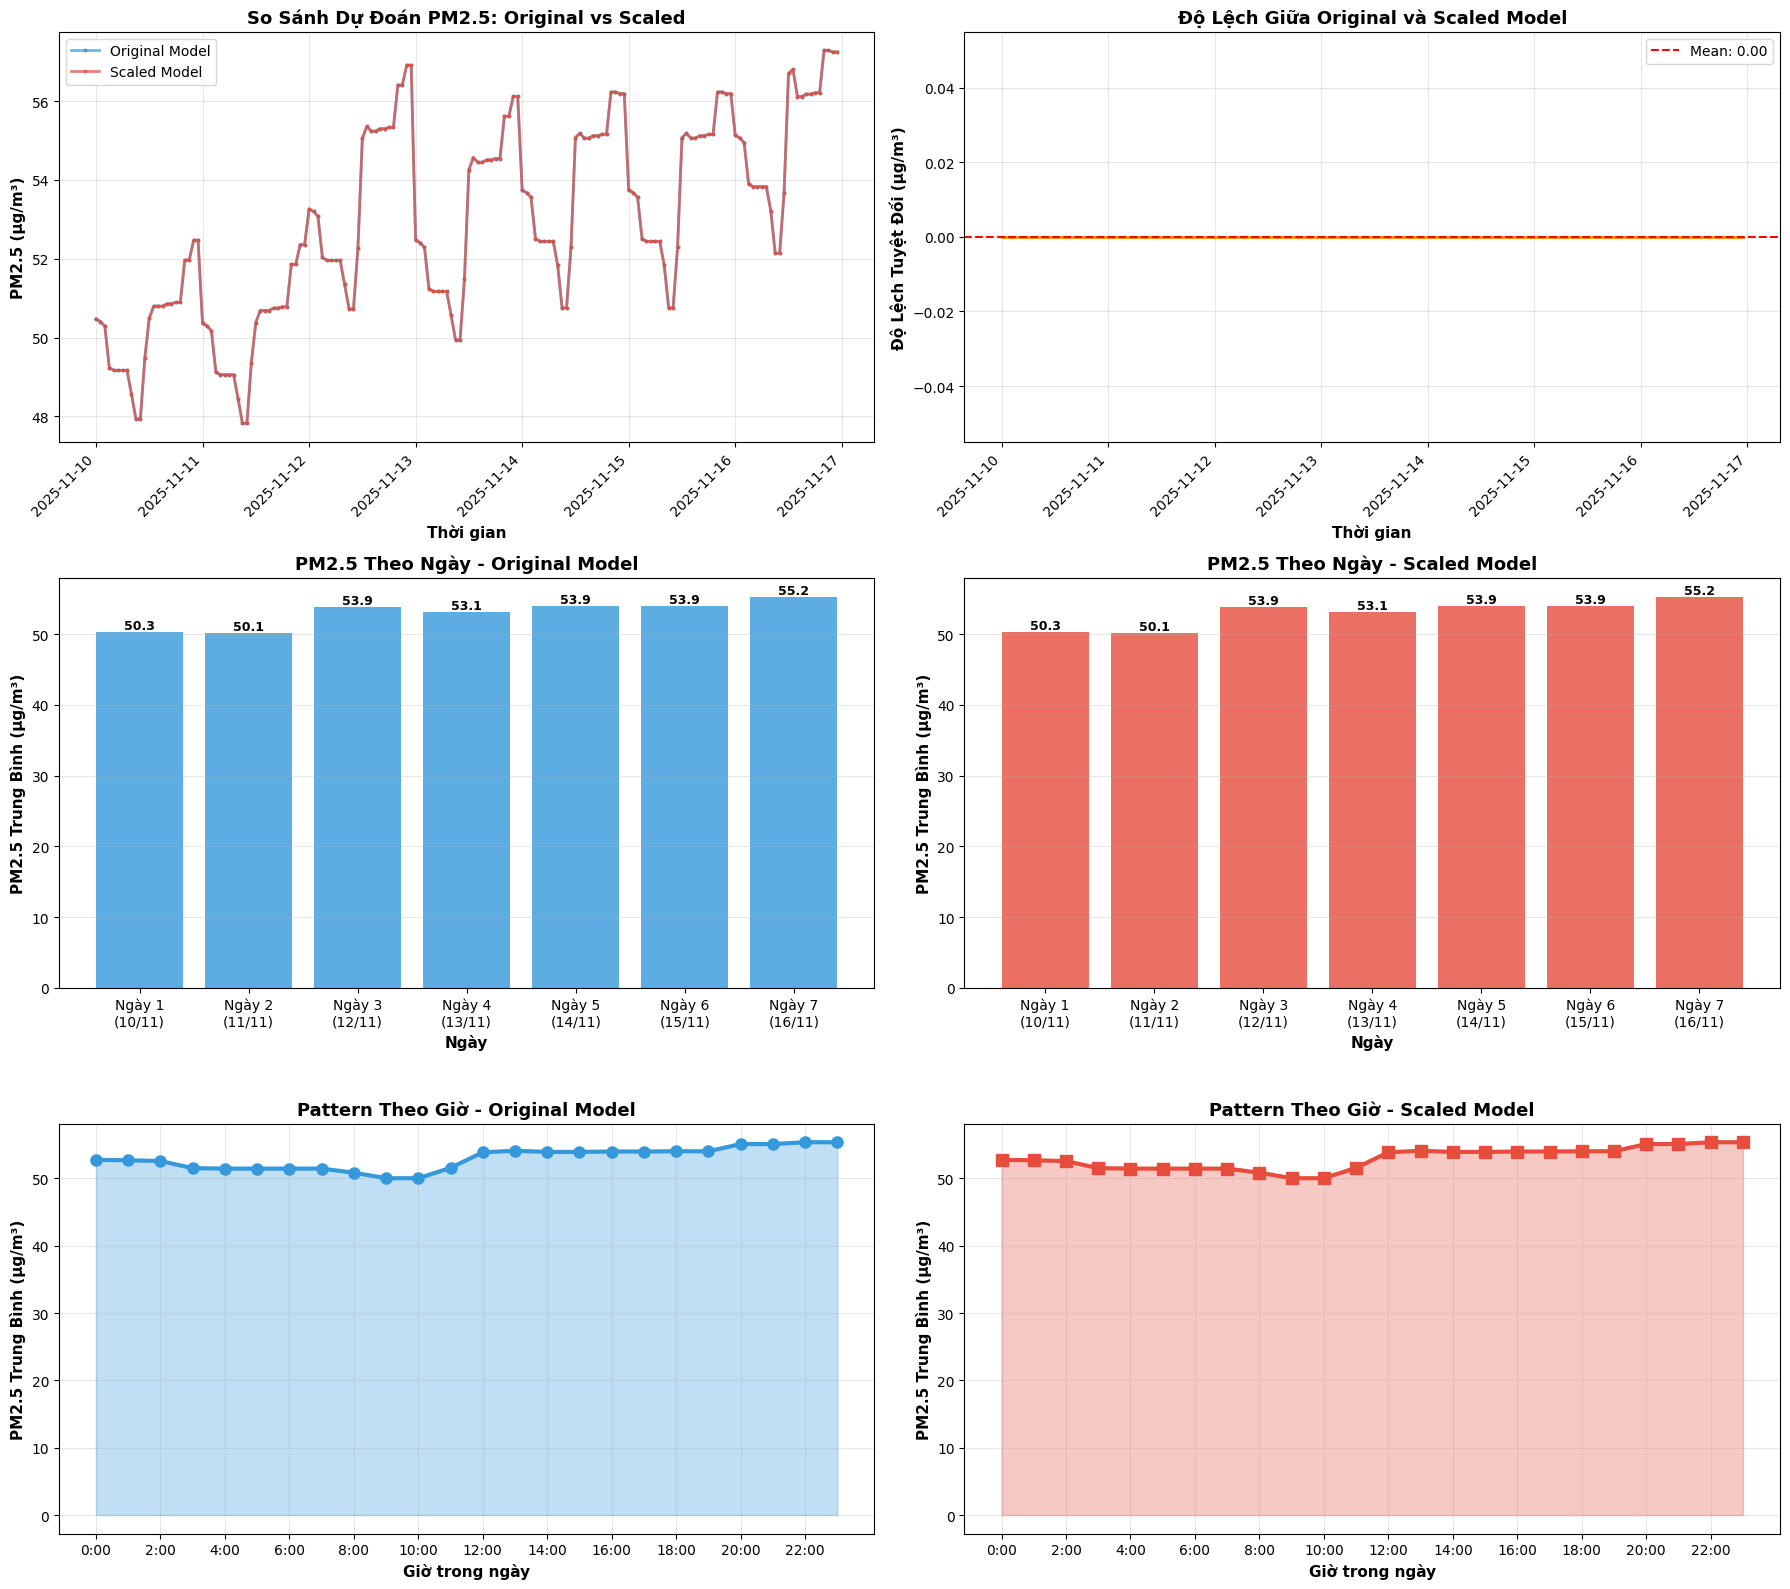

 Hoàn tất trực quan hóa!


In [19]:
print("\n TRỰC QUAN HÓA SO SÁNH KẾT QUẢ\n")

if 'pm25_predicted_original' in future_df.columns and 'pm25_predicted_scaled' in future_df.columns:
    fig, axes = plt.subplots(3, 2, figsize=(18, 16))
    
    # 1. So sánh PM2.5 theo giờ (168 giờ) - Cả hai mô hình
    ax1 = axes[0, 0]
    ax1.plot(future_df['datetime'], future_df['pm25_predicted_original'], 
             linewidth=2, color='#3498db', marker='o', markersize=2, 
             alpha=0.7, label='Original Model')
    ax1.plot(future_df['datetime'], future_df['pm25_predicted_scaled'], 
             linewidth=2, color='#e74c3c', marker='s', markersize=2, 
             alpha=0.7, label='Scaled Model')
    ax1.set_xlabel('Thời gian', fontsize=11, fontweight='bold')
    ax1.set_ylabel('PM2.5 (µg/m³)', fontsize=11, fontweight='bold')
    ax1.set_title('So Sánh Dự Đoán PM2.5: Original vs Scaled', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 2. Độ lệch giữa hai mô hình
    ax2 = axes[0, 1]
    ax2.fill_between(future_df['datetime'], future_df['difference'], 
                      alpha=0.5, color='orange')
    ax2.plot(future_df['datetime'], future_df['difference'], 
             linewidth=2, color='darkorange')
    ax2.set_xlabel('Thời gian', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Độ Lệch Tuyệt Đối (µg/m³)', fontsize=11, fontweight='bold')
    ax2.set_title('Độ Lệch Giữa Original và Scaled Model', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=future_df['difference'].mean(), color='red', 
                linestyle='--', label=f"Mean: {future_df['difference'].mean():.2f}")
    ax2.legend(fontsize=10)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 3. PM2.5 trung bình theo ngày - Original
    ax3 = axes[1, 0]
    daily_means_orig = []
    daily_labels = []
    for day in range(7):
        day_start = start_date + timedelta(days=day)
        day_end = day_start + timedelta(days=1)
        day_mask = (future_df['datetime'] >= day_start) & (future_df['datetime'] < day_end)
        daily_means_orig.append(future_df[day_mask]['pm25_predicted_original'].mean())
        daily_labels.append(day_start.strftime('%d/%m'))
    
    bars1 = ax3.bar(range(7), daily_means_orig, alpha=0.8, color='#3498db')
    ax3.set_xlabel('Ngày', fontsize=11, fontweight='bold')
    ax3.set_ylabel('PM2.5 Trung Bình (µg/m³)', fontsize=11, fontweight='bold')
    ax3.set_title('PM2.5 Theo Ngày - Original Model', fontsize=13, fontweight='bold')
    ax3.set_xticks(range(7))
    ax3.set_xticklabels([f'Ngày {i+1}\n({daily_labels[i]})' for i in range(7)])
    ax3.grid(axis='y', alpha=0.3)
    
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 4. PM2.5 trung bình theo ngày - Scaled
    ax4 = axes[1, 1]
    daily_means_scaled = []
    for day in range(7):
        day_start = start_date + timedelta(days=day)
        day_end = day_start + timedelta(days=1)
        day_mask = (future_df['datetime'] >= day_start) & (future_df['datetime'] < day_end)
        daily_means_scaled.append(future_df[day_mask]['pm25_predicted_scaled'].mean())
    
    bars2 = ax4.bar(range(7), daily_means_scaled, alpha=0.8, color='#e74c3c')
    ax4.set_xlabel('Ngày', fontsize=11, fontweight='bold')
    ax4.set_ylabel('PM2.5 Trung Bình (µg/m³)', fontsize=11, fontweight='bold')
    ax4.set_title('PM2.5 Theo Ngày - Scaled Model', fontsize=13, fontweight='bold')
    ax4.set_xticks(range(7))
    ax4.set_xticklabels([f'Ngày {i+1}\n({daily_labels[i]})' for i in range(7)])
    ax4.grid(axis='y', alpha=0.3)
    
    for i, bar in enumerate(bars2):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 5. Pattern theo giờ - Original
    ax5 = axes[2, 0]
    hourly_means_orig = future_df.groupby('hour')['pm25_predicted_original'].mean()
    ax5.plot(hourly_means_orig.index, hourly_means_orig.values, 
             linewidth=3, color='#3498db', marker='o', markersize=8)
    ax5.fill_between(hourly_means_orig.index, hourly_means_orig.values, 
                      alpha=0.3, color='#3498db')
    ax5.set_xlabel('Giờ trong ngày', fontsize=11, fontweight='bold')
    ax5.set_ylabel('PM2.5 Trung Bình (µg/m³)', fontsize=11, fontweight='bold')
    ax5.set_title('Pattern Theo Giờ - Original Model', fontsize=13, fontweight='bold')
    ax5.set_xticks(range(0, 24, 2))
    ax5.set_xticklabels([f'{h}:00' for h in range(0, 24, 2)])
    ax5.grid(True, alpha=0.3)
    
    # 6. Pattern theo giờ - Scaled
    ax6 = axes[2, 1]
    hourly_means_scaled = future_df.groupby('hour')['pm25_predicted_scaled'].mean()
    ax6.plot(hourly_means_scaled.index, hourly_means_scaled.values, 
             linewidth=3, color='#e74c3c', marker='s', markersize=8)
    ax6.fill_between(hourly_means_scaled.index, hourly_means_scaled.values, 
                      alpha=0.3, color='#e74c3c')
    ax6.set_xlabel('Giờ trong ngày', fontsize=11, fontweight='bold')
    ax6.set_ylabel('PM2.5 Trung Bình (µg/m³)', fontsize=11, fontweight='bold')
    ax6.set_title('Pattern Theo Giờ - Scaled Model', fontsize=13, fontweight='bold')
    ax6.set_xticks(range(0, 24, 2))
    ax6.set_xticklabels([f'{h}:00' for h in range(0, 24, 2)])
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(" Hoàn tất trực quan hóa!")
else:
    print("  Không thể trực quan hóa - Thiếu dữ liệu dự đoán")

In [22]:
print("\n" + "="*70)
print("XUẤT KẾT QUẢ DỰ ĐOÁN")
print("="*70 + "\n")

# Hàm đánh giá chất lượng không khí
def get_air_quality(pm25):
    if pm25 <= 12:
        return 'Good'
    elif pm25 <= 35.4:
        return 'Moderate'
    elif pm25 <= 55.4:
        return 'Unhealthy for Sensitive Groups'
    elif pm25 <= 150.4:
        return 'Unhealthy'
    elif pm25 <= 250.4:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

if 'pm25_predicted_original' in future_df.columns and 'pm25_predicted_scaled' in future_df.columns:
    # Tạo DataFrame kết quả
    result_df = future_df[['datetime', 'year', 'month', 'day', 'hour', 'weekday',
                            'pm25_predicted_original', 'pm25_predicted_scaled', 
                            'difference', 'difference_percent']].copy()
    
    result_df.columns = ['Datetime', 'Year', 'Month', 'Day', 'Hour', 'Weekday',
                         'PM25_Original', 'PM25_Scaled', 'Difference', 'Difference_Percent']
    
    # Thêm tên ngày trong tuần
    weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    result_df['Weekday_Name'] = result_df['Weekday'].apply(lambda x: weekday_names[x])
    
    # Thêm đánh giá chất lượng không khí cho cả hai mô hình
    result_df['Air_Quality_Original'] = result_df['PM25_Original'].apply(get_air_quality)
    result_df['Air_Quality_Scaled'] = result_df['PM25_Scaled'].apply(get_air_quality)
    
    # Thêm cột trung bình của hai mô hình
    result_df['PM25_Average'] = (result_df['PM25_Original'] + result_df['PM25_Scaled']) / 2
    result_df['Air_Quality_Average'] = result_df['PM25_Average'].apply(get_air_quality)
    
    # Lưu ra file CSV
    output_file = 'pm25_predictions_comparison_7days.csv'
    result_df.to_csv(output_file, index=False, encoding='utf-8-sig')
    
    print(f" Đã lưu kết quả vào file: {output_file}")
    print(f"   Số dòng: {len(result_df)}")
    print(f"   Các cột: {len(result_df.columns)}")
    
    # Thống kê chất lượng không khí - Original Model
    print(f"\n CHẤT LƯỢNG KHÔNG KHÍ - ORIGINAL MODEL:")
    print("-" * 70)
    air_quality_orig = result_df['Air_Quality_Original'].value_counts()
    for quality, count in air_quality_orig.items():
        percentage = (count / len(result_df)) * 100
        print(f"   {quality}: {count} giờ ({percentage:.1f}%)")
    
    # Thống kê chất lượng không khí - Scaled Model
    print(f"\n CHẤT LƯỢNG KHÔNG KHÍ - SCALED MODEL:")
    print("-" * 70)
    air_quality_scaled = result_df['Air_Quality_Scaled'].value_counts()
    for quality, count in air_quality_scaled.items():
        percentage = (count / len(result_df)) * 100
        print(f"   {quality}: {count} giờ ({percentage:.1f}%)")
    
    # Preview kết quả
    print(f"\n PREVIEW KẾT QUẢ (10 dòng đầu):")
    print("-" * 70)
    print(result_df[['Datetime', 'Hour', 'PM25_Original', 'PM25_Scaled', 
                     'Difference', 'Air_Quality_Original', 'Air_Quality_Scaled']].head(10).to_string(index=False))
    
else:
    print("  Không thể xuất kết quả - Thiếu dữ liệu dự đoán")

print("\n" + "="*70)


XUẤT KẾT QUẢ DỰ ĐOÁN

 Đã lưu kết quả vào file: pm25_predictions_comparison_7days.csv
   Số dòng: 168
   Các cột: 15

 CHẤT LƯỢNG KHÔNG KHÍ - ORIGINAL MODEL:
----------------------------------------------------------------------
   Unhealthy for Sensitive Groups: 140 giờ (83.3%)
   Unhealthy: 28 giờ (16.7%)

 CHẤT LƯỢNG KHÔNG KHÍ - SCALED MODEL:
----------------------------------------------------------------------
   Unhealthy for Sensitive Groups: 140 giờ (83.3%)
   Unhealthy: 28 giờ (16.7%)

 PREVIEW KẾT QUẢ (10 dòng đầu):
----------------------------------------------------------------------
           Datetime  Hour  PM25_Original  PM25_Scaled  Difference           Air_Quality_Original             Air_Quality_Scaled
2025-11-10 00:00:00     0      50.468296    50.468296         0.0 Unhealthy for Sensitive Groups Unhealthy for Sensitive Groups
2025-11-10 01:00:00     1      50.406960    50.406960         0.0 Unhealthy for Sensitive Groups Unhealthy for Sensitive Groups
2025-11-10 0

In [24]:
print("\n" + "="*70)
print("TÓM TẮT DỰ ĐOÁN")
print("="*70 + "\n")

if 'pm25_predicted_original' in future_df.columns and 'pm25_predicted_scaled' in future_df.columns:
    print(" THÔNG TIN CHUNG:")
    print(f"   • Thời gian dự đoán: {start_date.strftime('%Y-%m-%d')} đến {end_date.strftime('%Y-%m-%d')}")
    print(f"   • Tổng số dự đoán: {len(result_df)} giờ (7 ngày)")
    print(f"   • File kết quả: {output_file}")
    
    print(f"\n ORIGINAL MODEL:")
    print(f"   • Loại: {type(model_original).__name__}")
    print(f"   • PM2.5 trung bình: {result_df['PM25_Original'].mean():.2f} µg/m³")
    print(f"   • PM2.5 min-max: {result_df['PM25_Original'].min():.2f} - {result_df['PM25_Original'].max():.2f} µg/m³")
    print(f"   • Độ lệch chuẩn: {result_df['PM25_Original'].std():.2f} µg/m³")
    
    print(f"\n SCALED MODEL:")
    print(f"   • Loại: {type(model_scaled).__name__}")
    print(f"   • PM2.5 trung bình: {result_df['PM25_Scaled'].mean():.2f} µg/m³")
    print(f"   • PM2.5 min-max: {result_df['PM25_Scaled'].min():.2f} - {result_df['PM25_Scaled'].max():.2f} µg/m³")
    print(f"   • Độ lệch chuẩn: {result_df['PM25_Scaled'].std():.2f} µg/m³")
    
    print(f"\n SO SÁNH:")
    print(f"   • Độ lệch trung bình: {result_df['Difference'].mean():.2f} µg/m³")
    print(f"   • % lệch trung bình: {result_df['Difference_Percent'].mean():.2f}%")
    print(f"   • PM2.5 trung bình của cả hai: {result_df['PM25_Average'].mean():.2f} µg/m³")
    
    # Khuyến nghị
    print(f"\n KHUYẾN NGHỊ:")
    avg_pm25 = result_df['PM25_Average'].mean()
    if avg_pm25 <= 12:
        print("    Chất lượng không khí DỰ ĐOÁN TỐT trong 7 ngày tới")
    elif avg_pm25 <= 35.4:
        print("     Chất lượng không khí DỰ ĐOÁN Ở MỨC TRUNG BÌNH")
    elif avg_pm25 <= 55.4:
        print("     Chất lượng không khí DỰ ĐOÁN KHÔNG TỐT cho người nhạy cảm")
    else:
        print("    Chất lượng không khí DỰ ĐOÁN XẤU - Cần biện pháp bảo vệ")
    
else:
    print("  Không thể tạo tóm tắt - Thiếu dữ liệu dự đoán")


TÓM TẮT DỰ ĐOÁN

 THÔNG TIN CHUNG:
   • Thời gian dự đoán: 2025-11-10 đến 2025-11-17
   • Tổng số dự đoán: 168 giờ (7 ngày)
   • File kết quả: pm25_predictions_comparison_7days.csv

 ORIGINAL MODEL:
   • Loại: XGBRegressor
   • PM2.5 trung bình: 52.93 µg/m³
   • PM2.5 min-max: 47.83 - 57.28 µg/m³
   • Độ lệch chuẩn: 2.47 µg/m³

 SCALED MODEL:
   • Loại: XGBRegressor
   • PM2.5 trung bình: 52.93 µg/m³
   • PM2.5 min-max: 47.83 - 57.28 µg/m³
   • Độ lệch chuẩn: 2.47 µg/m³

 SO SÁNH:
   • Độ lệch trung bình: 0.00 µg/m³
   • % lệch trung bình: 0.00%
   • PM2.5 trung bình của cả hai: 52.93 µg/m³

 KHUYẾN NGHỊ:
     Chất lượng không khí DỰ ĐOÁN KHÔNG TỐT cho người nhạy cảm
